## Setup

In [2]:
# Imports
!pip install cptac
import cptac                     # Cancer Proteogenomic Analysis Consortium loader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px      # interactive charts
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import linkage, dendrogram  # optional
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D projection)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 69.0 MB/s eta 0:00:00
  Created wheel for sorted_nearest: filename=sorted_nearest-0.0.41-cp312-cp312-linux_x86_64.whl size=6676644 sha256=382719b4ac1596f11ea8d293347ddc8926dde188d901ea32929ec9d234f6358d
  Stored in directory: /root/.cache/pip/wheels/7c/cb/a4/a6f831a60e479b9001be190e91000cc472addeab871957e5a9
Successfully built sorted_nearest


In [3]:
# If we focused on a single cancer type, what data can be collected?
bc = cptac.Brca()  # for breast cancer...
bc.list_data_sources()
transcriptomics = bc.get_transcriptomics('broad')

## Section 1: Simple two-gene correlation + line of best fit

Lets explore the correlation between `ESR1` (estrogen receptor) and `PGR` (progesterone receptor) transcriptomics data.

In [4]:
# Find the transcript ID(s) available for ESR1 and PGR

print("ESR1 transcripts:", transcriptomics["ESR1"].columns.tolist())
print("PGR transcripts:", transcriptomics["PGR"].columns.tolist())

# how can we find how many transcriptomics IDs there are per gene?
# hint: we can use the len() function

ESR1 transcripts: [('ENST00000206249.7', 'ENSG00000091831.23'), ('ENST00000338799.9', 'ENSG00000091831.23'), ('ENST00000404742.5', 'ENSG00000091831.23'), ('ENST00000406599.5', 'ENSG00000091831.23'), ('ENST00000415488.1', 'ENSG00000091831.23'), ('ENST00000427531.6', 'ENSG00000091831.23'), ('ENST00000440973.5', 'ENSG00000091831.23'), ('ENST00000443427.5', 'ENSG00000091831.23'), ('ENST00000446550.1', 'ENSG00000091831.23'), ('ENST00000456483.3', 'ENSG00000091831.23'), ('ENST00000473497.5', 'ENSG00000091831.23'), ('ENST00000482101.1', 'ENSG00000091831.23'), ('ENST00000488573.1', 'ENSG00000091831.23'), ('ENST00000638569.1', 'ENSG00000091831.23'), ('ENST00000641399.1', 'ENSG00000091831.23')]
PGR transcripts: [('ENST00000263463.9', 'ENSG00000082175.15'), ('ENST00000325455.10', 'ENSG00000082175.15'), ('ENST00000526300.5', 'ENSG00000082175.15'), ('ENST00000528960.5', 'ENSG00000082175.15'), ('ENST00000530764.1', 'ENSG00000082175.15'), ('ENST00000533207.5', 'ENSG00000082175.15'), ('ENST00000534013

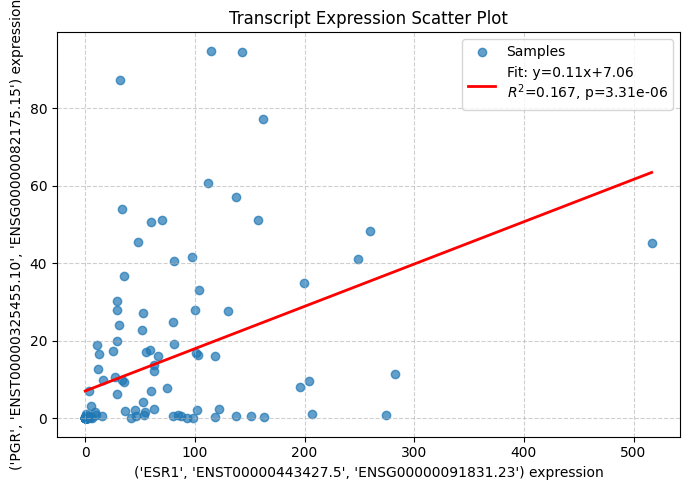

In [5]:
# 1. Pick two genes for a simple correlation demo
x_gene = ("ESR1", "ENST00000443427.5", "ENSG00000091831.23")  # <-- you can edit these from the list above
y_gene = ("PGR",  "ENST00000325455.10", "ENSG00000082175.15")  # <-- you can edit these from the list above

x = transcriptomics.loc[:, x_gene]
y = transcriptomics.loc[:, y_gene]

# 2. Combine into a single DataFrame and keep only samples with values for BOTH genes
xy = pd.concat([x, y], axis=1).dropna()
x_vals = xy[x_gene].to_numpy()
y_vals = xy[y_gene].to_numpy()

# 3. Fit a line of best fit (simple linear regression)
slope, intercept, r_value, p_value, std_err = stats.linregress(x_vals, y_vals)
x_fit = np.linspace(x_vals.min(), x_vals.max(), 100)
y_fit = slope * x_fit + intercept

# 4. Create the scatter plot with the fit line
plt.figure(figsize=(7, 5))
plt.scatter(x_vals, y_vals, alpha=0.7, label="Samples")
plt.plot(x_fit, y_fit, color='red', linewidth=2,
         label=f"Fit: y={slope:.2f}x+{intercept:.2f}\n$R^2$={r_value**2:.3f}, p={p_value:.2e}")
plt.xlabel(f"{x_gene} expression")
plt.ylabel(f"{y_gene} expression")
plt.title("Transcript Expression Scatter Plot")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## Section 2: Clustering on the PAM50 gene panel

The PAM50 panel [(Parker et al., 2009)](https://pmc.ncbi.nlm.nih.gov/articles/PMC2667820/) is the 50-gene Prediction Analysis of Microarray (PAM) signature clinicians use to analyze the tumor's biology, predict how aggressive it is, and guide treatment decisions. This dataset aims to classify Breast cancer into one of 4 subtypes: Luminal A, Luminal B, HER2-enriched, Basal-like.

Clustering on these genes lets us check whether unsupervised learning on transcriptomics data aligns with a clinically-relevant structure.

In [6]:
# PAM50 GENES -- the clinically established 50-gene breast cancer subtyping panel
# Transcripts hardcoded below (previously selected as the highest-variance transcript
# per gene) so the feature set is fixed and reproducible.
pam50_transcripts = {
    "ACTR3B": ('ENST00000256001.13', 'ENSG00000133627.18'),
    "ANLN": ('ENST00000265748.7', 'ENSG00000011426.11'),
    "BAG1": ('ENST00000379704.7', 'ENSG00000107262.25'),
    "BCL2": ('ENST00000333681.5', 'ENSG00000171791.13'),
    "BIRC5": ('ENST00000350051.8', 'ENSG00000089685.15'),
    "BLVRA": ('ENST00000265523.9', 'ENSG00000106605.11'),
    "CCNB1": ('ENST00000506572.5', 'ENSG00000134057.15'),
    "CCNE1": ('ENST00000262643.8', 'ENSG00000105173.14'),
    "CDC20": ('ENST00000310955.11', 'ENSG00000117399.14'),
    "CDC6": ('ENST00000649662.1', 'ENSG00000094804.12'),
    "CDH3": ('ENST00000567674.1', 'ENSG00000062038.14'),
    "CENPF": ('ENST00000469862.1', 'ENSG00000117724.13'),
    "CEP55": ('ENST00000371485.8', 'ENSG00000138180.16'),
    "CXXC5": ('ENST00000302517.8', 'ENSG00000171604.12'),
    "EGFR": ('ENST00000275493.7', 'ENSG00000146648.18'),
    "ERBB2": ('ENST00000541774.5', 'ENSG00000141736.13'),
    "ESR1": ('ENST00000443427.5', 'ENSG00000091831.23'),
    "EXO1": ('ENST00000348581.9', 'ENSG00000174371.17'),
    "FGFR4": ('ENST00000292408.9', 'ENSG00000160867.15'),
    "FOXA1": ('ENST00000250448.5', 'ENSG00000129514.8'),
    "FOXC1": ('ENST00000645831.2', 'ENSG00000054598.9'),
    "GPR160": ('ENST00000355897.10', 'ENSG00000173890.17'),
    "GRB7": ('ENST00000394211.7', 'ENSG00000141738.14'),
    "KIF2C": ('ENST00000372224.9', 'ENSG00000142945.13'),
    "KRT14": ('ENST00000167586.7', 'ENSG00000186847.6'),
    "KRT17": ('ENST00000311208.13', 'ENSG00000128422.17'),
    "KRT5": ('ENST00000252242.9', 'ENSG00000186081.12'),
    "MAPT": ('ENST00000446361.7', 'ENSG00000186868.15'),
    "MDM2": ('ENST00000540709.1', 'ENSG00000135679.25'),
    "MELK": ('ENST00000298048.7', 'ENSG00000165304.8'),
    "MIA": ('ENST00000594436.5', 'ENSG00000261857.7'),
    "MKI67": ('ENST00000368653.7', 'ENSG00000148773.14'),
    "MLPH": ('ENST00000338530.8', 'ENSG00000115648.14'),
    "MMP11": ('ENST00000215743.8', 'ENSG00000099953.10'),
    "MYBL2": ('ENST00000217026.5', 'ENSG00000101057.16'),
    "MYC": ('ENST00000377970.6', 'ENSG00000136997.20'),
    "NAT1": ('ENST00000307719.9', 'ENSG00000171428.14'),
    "NDC80": ('ENST00000261597.9', 'ENSG00000080986.13'),
    "NUF2": ('ENST00000271452.8', 'ENSG00000143228.13'),
    "PGR": ('ENST00000325455.10', 'ENSG00000082175.15'),
    "PHGDH": ('ENST00000641023.1', 'ENSG00000092621.12'),
    "PTTG1": ('ENST00000352433.10', 'ENSG00000164611.13'),
    "RRM2": ('ENST00000304567.10', 'ENSG00000171848.15'),
    "SFRP1": ('ENST00000379845.3', 'ENSG00000104332.12'),
    "SLC39A6": ('ENST00000269187.10', 'ENSG00000141424.13'),
    "TMEM45B": ('ENST00000281441.8', 'ENSG00000151715.8'),
    "TYMS": ('ENST00000323274.15', 'ENSG00000176890.16'),
    "UBE2C": ('ENST00000356455.9', 'ENSG00000175063.17'),
    "UBE2T": ('ENST00000646651.1', 'ENSG00000077152.11'),
}

# BUILD FEATURE DATAFRAME: pull each gene's hardcoded transcript directly from transcriptomics
feature_cols = {}
for gene, transcript_key in pam50_transcripts.items():
    feature_cols[gene] = transcriptomics.loc[:, (gene,) + transcript_key]

df = pd.DataFrame(feature_cols).dropna()
print(f"Matrix: {df.shape[0]} patients x {df.shape[1]} PAM50 genes")

Matrix: 121 patients x 49 PAM50 genes


In [7]:
# 1. STANDARDIZE + PCA
X = (df - df.mean()) / df.std(ddof=0)          # standardized matrix (patients x genes)
pca = PCA()
scores = pca.fit_transform(X)                  # shape: (n_patients, n_genes)
expl_var = pca.explained_variance_ratio_
cum_var = np.cumsum(expl_var)

# Keep enough PCs to reach >=95% cumulative variance (at least 2)
n_pc = max(2, np.searchsorted(cum_var, 0.95) + 1)
X_pcs = scores[:, :n_pc]
print(f"[1] PCA: Using first {n_pc} PCs (cumulative variance = {cum_var[n_pc-1]:.1%})")

[1] PCA: Using first 30 PCs (cumulative variance = 95.6%)


In [8]:
# 2. CHOOSE K AND FIT KMEANS (silhouette-based selection)
best_k = 2
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=0)
cluster_labels = kmeans.fit_predict(X_pcs)
print(f"[2] Fit KMeans with k={best_k}; cluster sizes: {np.bincount(cluster_labels)}")

[2] Fit KMeans with k=2; cluster sizes: [26 95]


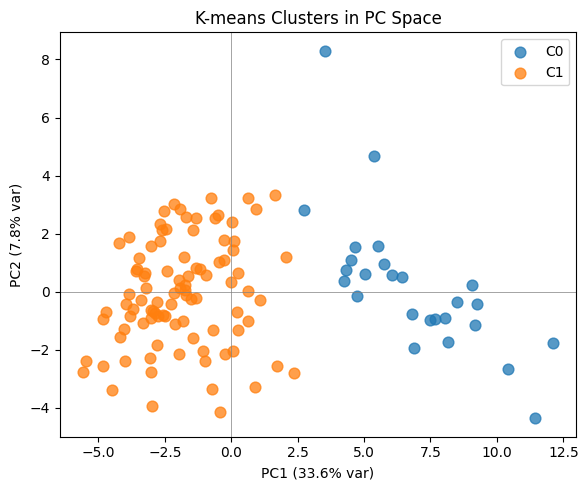

[4] Displayed clustered PC scatter plot.


In [9]:
# ------------------------------------------------------------
# 4. PC1 vs PC2 SCATTER (colored by cluster)
plt.figure(figsize=(6, 5))
for c in np.unique(cluster_labels):
    mask = cluster_labels == c
    plt.scatter(scores[mask, 0], scores[mask, 1], s=60, alpha=0.75, label=f"C{c}")
plt.xlabel(f"PC1 ({expl_var[0]:.1%} var)")
plt.ylabel(f"PC2 ({expl_var[1]:.1%} var)")
plt.title("K-means Clusters in PC Space")
plt.axhline(0, color="gray", lw=0.5)
plt.axvline(0, color="gray", lw=0.5)
plt.legend()
plt.tight_layout()
plt.show()
print("[4] Displayed clustered PC scatter plot.")

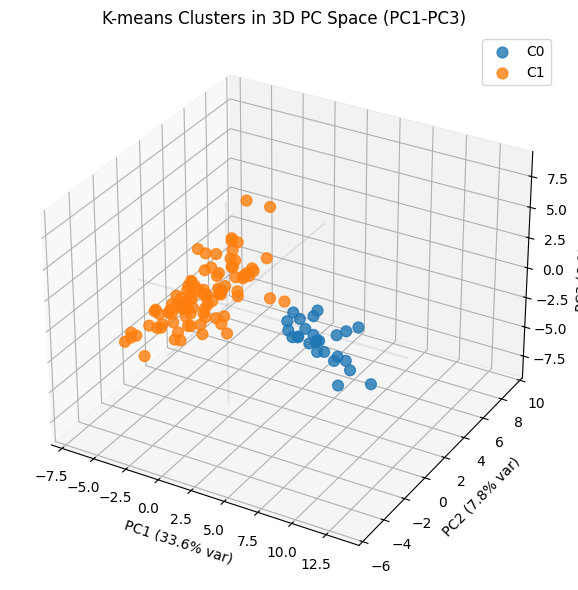

[4-3D] Displayed clustered 3D PC scatter plot.


In [10]:
# --- 3D PC1-PC2-PC3 scatter colored by cluster ---------------------------
if scores.shape[1] < 3:
    raise ValueError("PC3 not available: rerun PCA keeping at least 3 components.")

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

for c in np.unique(cluster_labels):
    mask = cluster_labels == c
    ax.scatter(
        scores[mask, 0],   # PC1
        scores[mask, 1],   # PC2
        scores[mask, 2],   # PC3
        s=60, alpha=0.8, label=f"C{c}"
    )

ax.set_xlabel(f"PC1 ({expl_var[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({expl_var[1]:.1%} var)")
ax.set_zlabel(f"PC3 ({expl_var[2]:.1%} var)")
ax.set_title("K-means Clusters in 3D PC Space (PC1-PC3)")

# Optional: light reference planes at 0
ax.plot([0,0],[0,0],[ax.get_zlim()[0], ax.get_zlim()[1]], color='gray', alpha=0.15)
ax.plot([0,0],[ax.get_ylim()[0], ax.get_ylim()[1]],[0,0], color='gray', alpha=0.15)
ax.plot([ax.get_xlim()[0], ax.get_xlim()[1]],[0,0],[0,0], color='gray', alpha=0.15)

ax.legend()
plt.tight_layout()
plt.show()
print("[4-3D] Displayed clustered 3D PC scatter plot.")

In [11]:
# 6. CLUSTER CENTROIDS (in PC space)
centroids = kmeans.cluster_centers_
centroid_df = pd.DataFrame(
    centroids,
    columns=[f"PC{i+1}" for i in range(n_pc)],
    index=[f"C{c}" for c in range(best_k)]
)
print("[6] Centroids (first PCs):")
display(centroid_df)

[6] Centroids (first PCs):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30
C0,6.842526,0.227646,-0.913165,-0.147466,-0.091462,0.231119,-0.084209,0.004039,0.094082,0.074947,...,0.074660,0.012425,0.044711,-0.022004,0.055873,0.071674,0.077845,0.035234,-0.034812,0.046904
C1,-1.872691,-0.062303,0.249919,0.040359,0.025032,-0.063254,0.023047,-0.001105,-0.025749,-0.020512,...,-0.020433,-0.003401,-0.012237,0.006022,-0.015291,-0.019616,-0.021305,-0.009643,0.009528,-0.012837


[7] Standardized per-cluster means:


,ACTR3B,ANLN,BAG1,BCL2,BIRC5,BLVRA,CCNB1,CCNE1,CDC20,CDC6,...,PGR,PHGDH,PTTG1,RRM2,SFRP1,SLC39A6,TMEM45B,TYMS,UBE2C,UBE2T
_cluster,,,,,,,,,,,,,,,,,,,,,
0,1.214339,1.039985,-0.339267,-0.693870,1.066396,-0.739661,1.153102,1.062475,1.413405,0.182382,...,-0.637091,1.179750,1.434514,0.765312,0.878525,-0.560303,-0.577365,1.224459,1.330535,1.148883
1,-0.332346,-0.284627,0.092852,0.189901,-0.291856,0.202434,-0.315586,-0.290783,-0.386827,-0.049915,...,0.174362,-0.322879,-0.392604,-0.209454,-0.240438,0.153346,0.158016,-0.335115,-0.364146,-0.314431


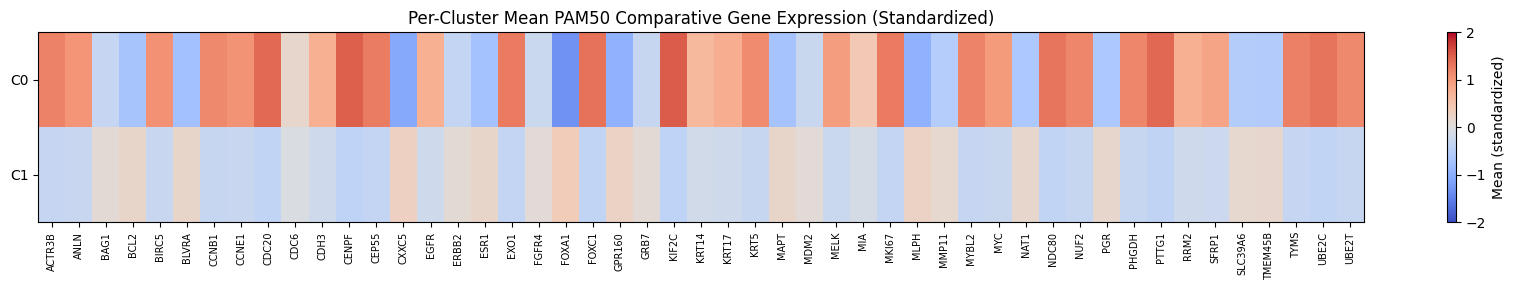


Cluster 0 genes sorted (descending):
KIF2C    1.526076
CENPF    1.484419
PTTG1    1.434514
CDC20    1.413405
FOXC1    1.358504
UBE2C    1.330535
NDC80    1.327098
EXO1     1.276170
MKI67    1.271877
CEP55    1.257360
Name: 0, dtype: float64

Cluster 1 genes sorted (descending):
FOXA1     0.362528
CXXC5     0.294724
GPR160    0.263900
MLPH      0.262358
BLVRA     0.202434
ESR1      0.200102
MAPT      0.195423
BCL2      0.189901
NAT1      0.174744
PGR       0.174362
Name: 1, dtype: float64


In [12]:
# 7. PER-CLUSTER FEATURE MEANS (standardized) + heatmap
cluster_means = (
    pd.DataFrame(X, index=df.index, columns=df.columns)
      .assign(_cluster=cluster_labels)
      .groupby("_cluster").mean()
      .sort_index()
)

print("[7] Standardized per-cluster means:")
display(cluster_means)

plt.figure(figsize=(len(df.columns)*0.35, 1.0*best_k + 1))
plt.imshow(cluster_means.values, aspect="auto", cmap="coolwarm", vmin=-2, vmax=2)
plt.colorbar(label="Mean (standardized)")
plt.yticks(range(best_k), [f"C{c}" for c in cluster_means.index])
plt.xticks(range(len(df.columns)), df.columns, rotation=90, ha="center", fontsize=7)
plt.title("Per-Cluster Mean PAM50 Comparative Gene Expression (Standardized)")
plt.tight_layout()
plt.show()

for c in cluster_means.index:
    print(f"\nCluster {c} genes sorted (descending):")
    print(cluster_means.loc[c].sort_values(ascending=False).head(10))

Basal-like or Luminal B: Characterized by high expression of basal cytokeratins and proliferation markers like:
**MKI67**, **CEP55**, **UBE2C**,**CDC20**,**PTTG1**.

Luminal A & B: Driven by luminal biomarkers, including:
**ESR1**, **FOXA1**, **MLPH**.

*Sources:*
* *[Breast cancer PAM50 signature: correlation and concordance between RNA-Seq and digital multiplexed gene expression technologies in a triple negative breast cancer series](https://pubmed.ncbi.nlm.nih.gov/31159741/)*
* *[PAM50 Breast Cancer Subtyping by RT-qPCR and Concordance with Standard Clinical Molecular Markers](https://pmc.ncbi.nlm.nih.gov/articles/PMC3487945/)*
* *[Proteomic maps of breast cancer subtypes](https://pmc.ncbi.nlm.nih.gov/articles/PMC4725767/)*
* *[Proteogenomic Landscape of Breast Cancer Tumorigenesis and Targeted Therapy
Author links open overlay panel](https://www.sciencedirect.com/science/article/pii/S0092867420314008)*
* *[Supervised Risk Predictor of Breast Cancer Based on Intrinsic Subtypes](https://pmc.ncbi.nlm.nih.gov/articles/PMC2667820/#sec23)*


## Section 3: Are the clusters clinically relevant? (if time)

Compare the unsupervised KMeans clusters against the PAM50 stage labels already assigned in the CPTAC clinical metadata.

[8] Values in 'tumor_stage_pathological':
tumor_stage_pathological
Stage II                                75
Stage III                               35
Staging is not applicable or unknown    20
Stage I                                  4
Name: count, dtype: int64

[8] 119 patients have both a cluster assignment and a tumor_stage_pathological value.
[8] Cluster vs. tumor_stage_pathological counts:


tumor_stage_pathological,Stage I,Stage II,Stage III,Staging is not applicable or unknown
KMeans_cluster,,,,
0.0,0,18,2,4
1.0,4,53,30,8


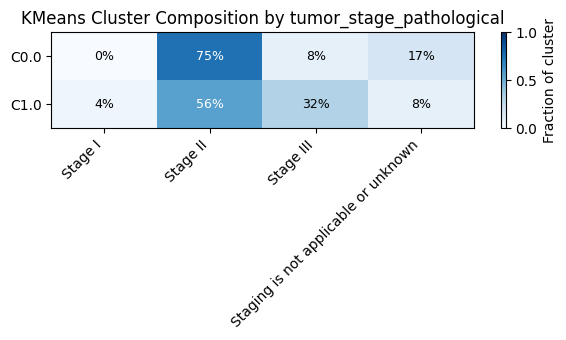

[8] Adjusted Rand Index (cluster vs. tumor_stage_pathological): -0.030


In [13]:
# 8. ANALYZE CLUSTERS AGAINST A CLINICAL VARIABLE
clinical = bc.get_clinical('mssm')
label_col = "tumor_stage_pathological"

print(f"[8] Values in '{label_col}':")
print(clinical[label_col].value_counts(dropna=False))

comparison = pd.DataFrame({
    label_col: clinical[label_col],
    "KMeans_cluster": pd.Series(cluster_labels, index=df.index),
}).dropna()

print(f"\n[8] {len(comparison)} patients have both a cluster assignment and a {label_col} value.")

ct = pd.crosstab(comparison["KMeans_cluster"], comparison[label_col])
print(f"[8] Cluster vs. {label_col} counts:")
display(ct)

ct_pct = ct.div(ct.sum(axis=1), axis=0)
plt.figure(figsize=(max(6, len(ct_pct.columns)*1.2), 1.0*best_k + 1.5))
plt.imshow(ct_pct.values, aspect="auto", cmap="Blues", vmin=0, vmax=1)
plt.colorbar(label="Fraction of cluster")
plt.yticks(range(len(ct_pct.index)), [f"C{c}" for c in ct_pct.index])
plt.xticks(range(len(ct_pct.columns)), ct_pct.columns, rotation=45, ha="right")
plt.title(f"KMeans Cluster Composition by {label_col}")
for i in range(ct_pct.shape[0]):
    for j in range(ct_pct.shape[1]):
        plt.text(j, i, f"{ct_pct.values[i,j]:.0%}", ha="center", va="center",
                  color="white" if ct_pct.values[i,j] > 0.5 else "black", fontsize=9)
plt.tight_layout()
plt.show()

ari = adjusted_rand_score(comparison[label_col], comparison["KMeans_cluster"])
print(f"[8] Adjusted Rand Index (cluster vs. {label_col}): {ari:.3f}")

In [18]:
clinical[label_col]

,tumor_stage_pathological
Patient_ID,
01BR001,Stage II
01BR008,Staging is not applicable or unknown
01BR009,Staging is not applicable or unknown
01BR010,Staging is not applicable or unknown
01BR015,Stage II
...,...
21BR010,Stage II
22BR003,Staging is not applicable or unknown
22BR005,Stage II
